**Mount Drive**

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Install libraries and imports**

In [ ]:
!pip -q install -U tqdm joblib
!pip -q install -U xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 20.8 MB/s eta 0:00:00


In [ ]:
# --- Imports + global config for readability ---
import os, re, json, math, random, itertools, warnings
from typing import List, Tuple, Dict

import xgboost as xgb
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path

from collections import defaultdict
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)
pd.set_option("display.max_colwidth", 140)


**Experiment Configuration**

In [ ]:
# ===== PATHS =====
DATA_DIR = "/content/drive/MyDrive/merged_data/merged_data"               # folder containing all your MergedXX.csv files
OUT_DIR  = "/content/drive/MyDrive/merged_data_results"       # where we write all artifacts (CSVs/plots/json)
os.makedirs(OUT_DIR, exist_ok=True)
print("Outputs will be saved under:", OUT_DIR)

# ===== LABEL + PROVENANCE HINTS =====
# Auto-detect the label column from these names (fallback = categorical with low cardinality)
TARGET_GUESS = ["Label", "label", "attack", "class"]
# Terms that mark columns we preserve unchanged for provenance/realism (never attacked)
ID_LIKE = [
    "flow_id","flow id","timestamp","time","ip","addr","src","dst",
    "port","proto","protocol","state","service","ipv","protocol_type","time_to_live"
]

# ===== DATA SPLIT & FEATURE SELECTION =====
TEST_SIZE   = 0.30    # 70/30 split
RFE_TOP_K   = 12      # select the 12 most informative features with RFE (on TRAIN only)

# ===== ADVERSARY BUDGETS / ASSIGNMENT REQUIREMENTS =====
MAX_FEATURES_CHANGED    = 3      # ≤3 features per flow (sparsity)
GLOBAL_EDIT_BUDGET_FRAC = 0.50   # across test set, edit budget ≤ 50%*(N_test*K)
MAX_QUERIES_PER_SAMPLE  = 80     # black-box query cap per sample

# ===== STEALTH-AWARE FITNESS WEIGHTS =====
W_COST_L0  = 0.25  # penalize number of features changed
W_COST_L1  = 0.10  # penalize magnitude of edits
W_PLAUS    = 0.60  # heavy penalty if plausibility/realism hard-check fails
W_QUERY    = 0.05  # small penalty proportional to queries used

# ===== BOUNDS POLICY FOR REALISM =====
# per-feature bound = ±max(20%*μ_benign, 2σ_benign) then clamped to observed [min,max] (from TRAIN BENIGN only)
BOUNDS_PCT   = 0.20
BOUNDS_SIGMA = 2.0

# ===== RANDOM SEED (REPRODUCIBILITY) =====
SEED = 42
random.seed(SEED); np.random.seed(SEED)


Outputs will be saved under: /content/drive/MyDrive/merged_data_results


**File utils, header normalization, label detection**

In [ ]:
def list_csvs(folder: str) -> List[str]:
    files = [os.path.join(folder, fn) for fn in os.listdir(folder) if fn.lower().endswith(".csv")]
    if not files:
        raise FileNotFoundError("No CSVs found in: " + folder)
    return sorted(files)

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    # CONSISTENT HEADERS → avoids silent bugs where "Flow ID" ≠ "flow id"
    df = df.copy()
    df.columns = [re.sub(r"\s+", "_", c.strip()) for c in df.columns]
    return df

def auto_label_col(df: pd.DataFrame, guesses: List[str]) -> str:
    #exact or case-insensitive matches from TARGET_GUESS; fallback to a low-cardinality categorical
    cols_lower = {c.lower(): c for c in df.columns}
    for g in guesses:
        if g in df.columns:
            return g
        if g.lower() in cols_lower:
            return cols_lower[g.lower()]
    cat_candidates = [c for c in df.columns if (df[c].dtype == "object" or df[c].nunique() <= 50)]
    if not cat_candidates:
        raise ValueError("Could not auto-detect label column. Please adjust TARGET_GUESS.")
    return cat_candidates[-1]

def columns_like(df: pd.DataFrame, needles: List[str]) -> List[str]:
    hits = []
    for c in df.columns:
        lc = c.lower().replace("_"," ")
        if any(n in lc for n in needles):
            hits.append(c)
    return hits


**Load all CSVs**

In [ ]:
dfs = []
for path in list_csvs(DATA_DIR):
    print("Loading:", path)
    df = pd.read_csv(path)
    dfs.append(normalize_columns(df))

raw = pd.concat(dfs, ignore_index=True)
print("Raw shape:", raw.shape)

LABEL_COL       = auto_label_col(raw, TARGET_GUESS)
PROVENANCE_COLS = list(set(columns_like(raw, ID_LIKE)))
print("Using label:", LABEL_COL)
print("Provenance cols (kept unchanged):", PROVENANCE_COLS[:12], f"... total: {len(PROVENANCE_COLS)}")


Loading: /content/drive/MyDrive/merged_data/merged_data/Merged01.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged02.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged03.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged04.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged05.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged06.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged07.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged08.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged09.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged10.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged11.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged12.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged13.csv
Loading: /content/drive/MyDrive/merged_data/merged_data/Merged14.csv
Loading: /content/drive/MyDrive/me

**Preprocessing (label mapping, numeric cleaning, encoding, scaling)**

In [ ]:
# WHY: turn raw strings into clean numeric arrays that models/attacks can use safely.
# CONSEQUENCES IF SKIPPED: scaler/fit crashes (Inf/NaN), outlier domination, and leakage.

def make_binary_labels(y: pd.Series) -> pd.Series:
    s = y.astype(str).str.lower().str.strip()
    return s.apply(lambda v: "Benign" if (v in ("0","normal","none","noattack","nan","") or "benign" in v) else "Malicious")

y_raw = raw[LABEL_COL]
y     = make_binary_labels(y_raw)

provenance_df = raw[PROVENANCE_COLS] if PROVENANCE_COLS else pd.DataFrame(index=raw.index)
X = raw.drop(columns=[LABEL_COL], errors="ignore").copy()

def coerce_numeric_like(X: pd.DataFrame) -> pd.DataFrame:
    # Promote object columns that are ~numeric to real floats (e.g., "1,234" -> 1234)
    X = X.copy()
    for c in X.columns:
        if X[c].dtype == "object":
            s = pd.to_numeric(X[c].astype(str).str.replace(",",""), errors="coerce")
            if s.notna().mean() >= 0.90:  # mostly numeric → keep numeric
                X[c] = s
    return X

X = coerce_numeric_like(X)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

num_cols_original = num_cols.copy()

def sanitize_numeric_block(X: pd.DataFrame, num_cols: List[str]) -> Tuple[pd.DataFrame, List[str]]:
    X = X.copy()
    kept = []
    for c in list(num_cols):
        s = pd.to_numeric(X[c], errors="coerce")      # force numeric
        s = s.replace([np.inf, -np.inf], np.nan)
        if s.notna().sum() == 0:                      # all NaN → drop
            X.drop(columns=[c], inplace=True)
            continue
        q_lo, q_hi = s.quantile([0.001, 0.999])       # winsorize tails
        s = s.clip(q_lo, q_hi).fillna(s.median())     # impute median
        if np.nanstd(s.values) == 0.0:                # constant → drop
            X.drop(columns=[c], inplace=True)
            continue
        X[c] = s.astype(np.float64)
        kept.append(c)
    return X, kept

X, num_cols = sanitize_numeric_block(X, num_cols)

scaler = StandardScaler()
if num_cols:
    X[num_cols] = scaler.fit_transform(X[num_cols].values)

encoders = {}
for c in cat_cols:
    if c not in X.columns: continue
    if X[c].isna().any():
        mode = X[c].mode()
        X[c] = X[c].fillna(mode.iloc[0] if not mode.empty else "missing")
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

print("Preprocessing complete:",
      "\n  Total features:", X.shape[1],
      "\n  Numeric:", len(num_cols), "| Categorical:", len(cat_cols))


Preprocessing complete: 
  Total features: 33 
  Numeric: 33 | Categorical: 0


**Define tweakable features**

In [ ]:
# WHY: attacks must be realistic → only tweak numeric flow statistics; never change identity, ports, protocol, or header fields.

FORBID_KEYS = [
    "ip","addr","port","proto","protocol","state","service","timestamp","time",
    "ipv","protocol_type","time_to_live","header",   # header/protocol/meta
    "tcp","udp","icmp","dns","http","https","smtp","ssh","telnet","irc","arp","igmp","llc"  # protocol-usage
]

def allowed_tweakable_features(df: pd.DataFrame, numeric_cols: List[str]) -> List[str]:
    keep = []
    for c in numeric_cols:
        lc = c.lower()
        if any(k in lc for k in FORBID_KEYS):
            continue
        keep.append(c)
    return keep

TWEAKABLE = allowed_tweakable_features(X, num_cols)
print("Tweakable numeric features (attackable):", len(TWEAKABLE))


Tweakable numeric features (attackable): 20


**Stratified 70/30 split, RFE on TRAIN only, and save splits to CSV **

In [ ]:
# Uses your existing: X, y, provenance_df, OUT_DIR, SEED, TEST_SIZE, RFE_TOP_K

# Reuse your globals if set
#SEED        = globals().get("SEED", 42)
#TEST_SIZE   = globals().get("TEST_SIZE", 0.30)
#RFE_TOP_K   = globals().get("RFE_TOP_K", 12)

# To keep RFE tractable on huge data, fit RFE on a stratified TRAIN subset of at most this many rows
RFE_SAMPLE_MAX = globals().get("RFE_SAMPLE_MAX", 5_000_000)  # raise if your VM can handle more

out_dir = Path(globals().get("OUT_DIR", "./outputs"))
out_dir.mkdir(parents=True, exist_ok=True)

# 1) Stratified split (70/30) with train_test_split
if 'provenance_df' in globals() and isinstance(provenance_df, pd.DataFrame) and len(provenance_df) == len(X):
    X_train, X_test, y_train, y_test, prov_train, prov_test = train_test_split(
        X, y, provenance_df, test_size=TEST_SIZE, stratify=y, random_state=SEED
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
    )
    prov_train = pd.DataFrame(index=X_train.index)
    prov_test  = pd.DataFrame(index=X_test.index)

print("Split shapes | Train:", X_train.shape, " Test:", X_test.shape)

# 2) RFE on TRAIN only (optionally on a stratified TRAIN subset for speed)
if len(X_train) > RFE_SAMPLE_MAX:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=RFE_SAMPLE_MAX, random_state=SEED)
    y_train_bin = (y_train == "Malicious").astype(int).to_numpy()
    sub_idx, _ = next(sss.split(np.zeros_like(y_train_bin), y_train_bin))
    X_rfe = X_train.iloc[sub_idx]
    y_rfe = y_train.iloc[sub_idx]
    print(f"RFE on stratified TRAIN subset: {len(X_rfe)} rows")
else:
    X_rfe, y_rfe = X_train, y_train
    print(f"RFE on full TRAIN: {len(X_rfe)} rows")

rf_for_rfe = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
selector   = RFE(estimator=rf_for_rfe, n_features_to_select=RFE_TOP_K, step=0.1)
selector.fit(X_rfe, y_rfe)

selected_feats = X_train.columns[selector.support_].tolist()
print("Selected features (Top-{}):".format(RFE_TOP_K), selected_feats)

# 3) Materialize TRAIN/TEST with only the selected features, then save
X_train_sel = X_train[selected_feats].copy()
X_test_sel  = X_test[selected_feats].copy()

# Save (keep index for traceability)
X_train_sel.to_csv(out_dir / "X_train_selected.csv", index=True)
X_test_sel.to_csv( out_dir / "X_test_selected.csv",  index=True)
y_train.to_frame("Label").to_csv(out_dir / "y_train.csv", index=True)
y_test.to_frame("Label").to_csv( out_dir / "y_test.csv", index=True)
prov_train.to_csv(out_dir / "provenance_train.csv", index=True)
prov_test.to_csv( out_dir / "provenance_test.csv",  index=True)
with open(out_dir / "selected_features.txt", "w") as f:
    for c in selected_feats:
        f.write(c + "\n")

print("Saved splits & selected features →", out_dir)


Split shapes | Train: (17179517, 33)  Test: (7362651, 33)
RFE on stratified TRAIN subset: 5000000 rows
Selected features (Top-12): ['Header_Length', 'Time_To_Live', 'Rate', 'HTTPS', 'Tot_sum', 'Max', 'AVG', 'Std', 'Tot_size', 'IAT', 'Number', 'Variance']
Saved splits & selected features → /content/drive/MyDrive/merged_data_results


**Integrity check: All attack typess present**

In [ ]:
# === 10) Integrity check: attack-type coverage in TRAIN vs TEST ===

OUT_DIR = Path(OUT_DIR) if not isinstance(OUT_DIR, Path) else OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 0) Get TRAIN / TEST indices (from split_indices, or from y_train / y_test)
if 'train_idx' in globals() and 'test_idx' in globals():
    train_idx_use = train_idx
    test_idx_use  = test_idx
else:
    # y_train / y_test came from your split, so their index is exactly what we need
    train_idx_use = y_train.index
    test_idx_use  = y_test.index

# 1) Attack-type series from original LABEL column
attack_type_all = raw[LABEL_COL].astype(str).str.strip()

attack_type_train = attack_type_all.loc[train_idx_use]
attack_type_test  = attack_type_all.loc[test_idx_use]

# only malicious flows
mal_train_mask = (y.loc[train_idx_use] == "Malicious")
mal_test_mask  = (y.loc[test_idx_use]  == "Malicious")

fam_train_counts = attack_type_train[mal_train_mask].value_counts().sort_index()
fam_test_counts  = attack_type_test[mal_test_mask].value_counts().sort_index()

# 2) Combined table
fam_counts = (
    pd.DataFrame({
        "train_count": fam_train_counts,
        "test_count":  fam_test_counts
    })
    .fillna(0)
    .astype(int)
)

fam_counts["in_train"] = fam_counts["train_count"] > 0
fam_counts["in_test"]  = fam_counts["test_count"] > 0
fam_counts["in_both"]  = fam_counts["in_train"] & fam_counts["in_test"]

# 3) Print summary + table
missing_in_test  = fam_counts.index[(fam_counts["train_count"] > 0) & (fam_counts["test_count"] == 0)]
missing_in_train = fam_counts.index[(fam_counts["test_count"] > 0) & (fam_counts["train_count"] == 0)]

print("Attack-type coverage table (TRAIN vs TEST):")
display(fam_counts.sort_values("train_count", ascending=False))

print("\nMissing in TEST :", list(missing_in_test)  or ["None"])
print("Missing in TRAIN:", list(missing_in_train) or ["None"])

# 4) Save for report
fam_counts.to_csv(OUT_DIR / "integrity_family_counts.csv", index=True)
print("Saved:", OUT_DIR / "integrity_family_counts.csv")


Attack-type coverage table (TRAIN vs TEST):


,train_count,test_count,in_train,in_test,in_both
Label,,,,,
DDOS-ICMP_FLOOD,2629660,1127342,True,True,True
DDOS-UDP_FLOOD,1974988,847180,True,True,True
DDOS-TCP_FLOOD,1645058,703481,True,True,True
DDOS-PSHACK_FLOOD,1495538,642266,True,True,True
DDOS-SYN_FLOOD,1483594,635467,True,True,True
DDOS-RSTFINFLOOD,1480056,632089,True,True,True
DDOS-SYNONYMOUSIP_FLOOD,1314571,563413,True,True,True
DOS-UDP_FLOOD,1211762,520250,True,True,True
DOS-TCP_FLOOD,977197,417917,True,True,True



Missing in TEST : ['None']
Missing in TRAIN: ['None']
Saved: /content/drive/MyDrive/merged_data_results/integrity_family_counts.csv


**Audit: what got dropped / excluded**

In [ ]:
# === 11) Audit: dropped by sanitizer vs excluded from model ===
_selected_feats = selected_feats
_prov_cols      = PROVENANCE_COLS
_label_col      = LABEL_COL
_num_cols_orig  = num_cols_original
_num_cols_after = num_cols

dropped_numeric = sorted(set(_num_cols_orig) - set(_num_cols_after))
print("Dropped by sanitizer (all-NaN/constant or coerced away):", dropped_numeric)

excluded_for_model = sorted(
    c for c in X.columns
    if c not in _selected_feats
    and c not in _prov_cols
    and c != _label_col
)
print("Excluded from model (not in top-12, but still exist in dataset):", excluded_for_model)

pd.Series(dropped_numeric).to_csv(OUT_DIR / "audit_dropped_by_sanitizer.csv", index=False)
pd.Series(excluded_for_model).to_csv(OUT_DIR / "audit_excluded_from_model.csv", index=False)


Dropped by sanitizer (all-NaN/constant or coerced away): ['IGMP', 'IRC', 'SMTP', 'Telnet', 'cwr_flag_number', 'ece_flag_number']
Excluded from model (not in top-12, but still exist in dataset): ['ARP', 'DHCP', 'DNS', 'HTTP', 'ICMP', 'LLC', 'Min', 'SSH', 'TCP', 'UDP', 'ack_count', 'ack_flag_number', 'fin_count', 'fin_flag_number', 'psh_flag_number', 'rst_count', 'rst_flag_number', 'syn_count', 'syn_flag_number']


**Benign-only bounds (TRAIN) for tweakable features**

In [ ]:
# === Compute realism bounds on TRAIN Benign (benign-only limits for tweakable features) ===
# uses: X_train_sel, y_train, TWEAKABLE, BOUNDS_PCT, BOUNDS_SIGMA, OUT_DIR

OUT_DIR = Path(OUT_DIR)

train_benign_mask = (y_train == "Benign")

# per-feature min/max on TRAIN (all classes), for clamping
feat_mins = X_train_sel.min().to_dict()
feat_maxs = X_train_sel.max().to_dict()

BOUNDS = {}

for f in TWEAKABLE:
    # some tweakable features may have been dropped by RFE → skip if not in X_train_sel
    if f not in X_train_sel.columns:
        continue

    # benign-only values for this feature
    arr = X_train_sel.loc[train_benign_mask, f].values
    if arr.size == 0:
        # no benign data for this feature → skip
        continue

    mu = float(np.mean(arr))
    sd = float(np.std(arr) + 1e-9)

    # symmetric band around benign mean, using your policy
    lo_mu = mu - max(BOUNDS_SIGMA*sd, abs(mu)*BOUNDS_PCT)
    hi_mu = mu + max(BOUNDS_SIGMA*sd, abs(mu)*BOUNDS_PCT)

    # clamp to observed global min/max for safety
    lo = max(lo_mu, feat_mins.get(f, lo_mu))
    hi = min(hi_mu, feat_maxs.get(f, hi_mu))

    BOUNDS[f] = (lo, hi)

print("Bounds computed for tweakable features:", len(BOUNDS))

# quick preview of first 5
print("Example bounds (first 5):")
for k, v in list(BOUNDS.items())[:5]:
    print(f"  {k}: lo={v[0]:.4f}, hi={v[1]:.4f}")

# save to CSV if you want it for the report
bounds_df = pd.DataFrame(BOUNDS, index=["lo", "hi"]).T
bounds_df.to_csv(OUT_DIR / "bounds_benign_only.csv")
print("Saved bounds to:", OUT_DIR / "bounds_benign_only.csv")



Bounds computed for tweakable features: 9
Example bounds (first 5):
  Rate: lo=-1.0702, hi=0.6120
  Tot_sum: lo=-0.6171, hi=0.5223
  Max: lo=-0.3031, hi=9.1094
  AVG: lo=-0.3175, hi=7.7202
  Std: lo=-0.2438, hi=9.5311
Saved bounds to: /content/drive/MyDrive/merged_data_results/bounds_benign_only.csv


**Random Forest baseline with ROC plot**

RF (baseline, clean TEST) | ACC=0.9922  PREC=0.9961  REC=0.9959  F1=0.9960  AUC=0.9976
Saved: /content/drive/MyDrive/merged_data_results/roc_rf_clean.png


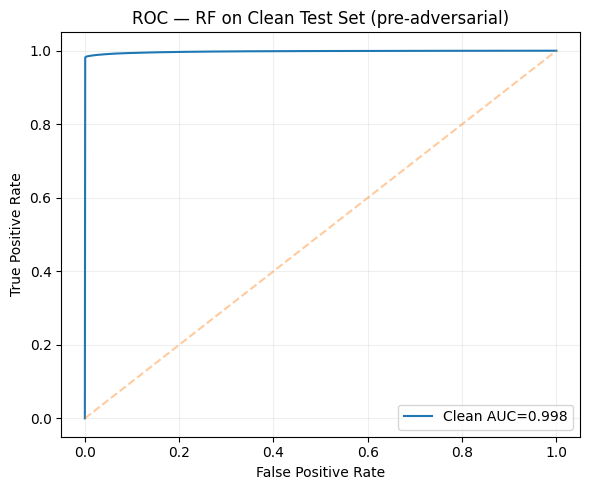

In [ ]:
# === Train RF baseline (Top-12) on TRAIN & evaluate on CLEAN TEST + ROC (pre-adversarial) ===

rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)
rf.fit(X_train_sel, y_train)

def eval_clf(name, clf, Xte, yte):
    proba = clf.predict_proba(Xte)[:,1]
    pred  = clf.predict(Xte)
    res = {
        "ACC":  accuracy_score(yte, pred),
        "PREC": precision_score(yte, pred, pos_label="Malicious"),
        "REC":  recall_score(yte, pred, pos_label="Malicious"),
        "F1":   f1_score(yte, pred, pos_label="Malicious"),
        "AUC":  roc_auc_score((yte=="Malicious").astype(int), proba)
    }
    print(f"{name} | ACC={res['ACC']:.4f}  PREC={res['PREC']:.4f}  REC={res['REC']:.4f}  F1={res['F1']:.4f}  AUC={res['AUC']:.4f}")
    return res, proba, pred

clean_res, clean_proba, clean_pred = eval_clf("RF (baseline, clean TEST)", rf, X_test_sel, y_test)

y_true_bin = (y_test=="Malicious").astype(int).values
fpr_clean, tpr_clean, _ = roc_curve(y_true_bin, clean_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr_clean, tpr_clean, label=f"Clean AUC={clean_res['AUC']:.3f}")
plt.plot([0,1],[0,1],'--', alpha=.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — RF on Clean Test Set (pre-adversarial)")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout()
plt.savefig(OUT_DIR / "roc_rf_clean.png", dpi=160)
print("Saved:", OUT_DIR / "roc_rf_clean.png")


**Fitness, plausibility checks, and GA/PSO**

In [ ]:
# ===== Plausibility (hard) checks =====
def plausibility_ok(x_before: np.ndarray, x_after: np.ndarray, feat_names: List[str]) -> bool:
    # Keep simple universal invariants: finite & roughly non-extreme after scaling. Avoid negative "huge" values.
    if not np.isfinite(x_after).all(): return False
    if (x_after < -5.0).any():        return False     # scaled features can dip <0; allow small negatives only
    return True

# ===== Fitness function (lower is better) =====
def fitness(clf, x0, mask_tweakable, feat_names, bounds, query_cap=MAX_QUERIES_PER_SAMPLE):
    n = len(feat_names)
    b_lo = np.array([bounds.get(f, (-np.inf, np.inf))[0] for f in feat_names], dtype=float)
    b_hi = np.array([bounds.get(f, (-np.inf, np.inf))[1] for f in feat_names], dtype=float)
    queries = 0
    def _score(delta):
        nonlocal queries
        d = np.zeros_like(delta)
        idx = np.where(mask_tweakable)[0]
        if idx.size > 0:
            k = min(MAX_FEATURES_CHANGED, idx.size)
            top = idx[np.argsort(-np.abs(delta[idx]))[:k]]
            d[top] = delta[top]
        x1 = np.clip(x0 + d, b_lo, b_hi)
        if not plausibility_ok(x0, x1, feat_names): return 1e6
        p_benign = clf.predict_proba(x1.reshape(1,-1))[0,0]
        queries += 1
        l0 = (np.abs(d) > 1e-12).sum() / max(1, k)
        l1 = np.mean(np.abs(d))
        return (1 - p_benign) + W_COST_L0*l0 + W_COST_L1*l1 + W_QUERY*(queries/query_cap)
    return _score

# ===== GA =====
def run_ga(clf, x0, mask_tweakable, feat_names, bounds, gens=24, pop=24):
    n = len(feat_names)
    score_fn = fitness(clf, x0, mask_tweakable, feat_names, bounds)
    P = [np.random.normal(0, 0.15, size=n) for _ in range(pop)]
    scores = [score_fn(ind) for ind in P]
    best_idx = int(np.argmin(scores)); best = (P[best_idx].copy(), scores[best_idx])
    for _ in range(gens):
        newP = []
        for __ in range(pop):
            i, j = np.random.randint(0,pop), np.random.randint(0,pop)
            parent = P[i] if scores[i] < scores[j] else P[j]
            child  = parent + np.random.normal(0, 0.10, size=n)
            newP.append(child)
        P = newP
        scores = [score_fn(ind) for ind in P]
        gbest_idx = int(np.argmin(scores))
        if scores[gbest_idx] < best[1]:
            best = (P[gbest_idx].copy(), scores[gbest_idx])
    return best[0]

# ===== PSO =====
def run_pso(clf, x0, mask_tweakable, feat_names, bounds, iters=45, swarm=18):
    n = len(feat_names)
    score_fn = fitness(clf, x0, mask_tweakable, feat_names, bounds)
    Xp = [np.random.normal(0, 0.15, size=n) for _ in range(swarm)]
    V  = [np.zeros(n) for _ in range(swarm)]
    pbest = [xp.copy() for xp in Xp]
    pscore= [score_fn(xp) for xp in Xp]
    gbest = pbest[int(np.argmin(pscore))].copy()
    gscore= float(np.min(pscore))
    w, c1, c2 = 0.7, 1.2, 1.2
    for _ in range(iters):
        for i in range(swarm):
            r1, r2 = np.random.rand(n), np.random.rand(n)
            V[i]  = w*V[i] + c1*r1*(pbest[i]-Xp[i]) + c2*r2*(gbest-Xp[i])
            Xp[i] = Xp[i] + V[i]
            s     = score_fn(Xp[i])
            if s < pscore[i]:
                pbest[i], pscore[i] = Xp[i].copy(), s
                if s < gscore:
                    gbest, gscore = Xp[i].copy(), s
    return gbest


**Choose targets, enforce global budget, generate adversarials for GA**

In [ ]:
# === GA-only: per-family targets, global budget, generate adversarial flows ===

# ---- sanity checks ----
if not hasattr(rf, "estimators_"):
    raise RuntimeError("RF not fitted; run the RF baseline cell first.")

if "X_test_sel" not in globals() or "y_test" not in globals():
    raise RuntimeError("X_test_sel / y_test not found. Run split + feature selection first.")

if "y_raw" not in globals():
    raise RuntimeError("y_raw (original attack families) not found from preprocessing step.")

if not TWEAKABLE:
    raise RuntimeError("TWEAKABLE is empty. Check 'Define tweakable features' cell.")

if not BOUNDS:
    raise RuntimeError("BOUNDS is empty. Run 'Benign-only bounds (TRAIN) for tweakable features' first.")

# ---- align test features to RF expectation if needed ----
if hasattr(rf, "feature_names_in_"):
    rf_order = list(rf.feature_names_in_)
    if rf_order != list(X_test_sel.columns):
        X_test_sel = X_test_sel.reindex(columns=rf_order)
        if X_test_sel.isna().any().any():
            raise RuntimeError("Column reordering introduced NaNs. Check preprocessing/splits.")

feat_names = list(X_test_sel.columns)
mask_tweak = np.array([f in set(TWEAKABLE) for f in feat_names], dtype=bool)
if mask_tweak.sum() == 0:
    raise RuntimeError("No tweakable features among selected features.")

# bounds vectors for clipping
b_lo = np.array([BOUNDS.get(f, (-np.inf, np.inf))[0] for f in feat_names], dtype=float)
b_hi = np.array([BOUNDS.get(f, (-np.inf, np.inf))[1] for f in feat_names], dtype=float)

# ---- original attack families on TEST set ----
family_test = y_raw.loc[y_test.index]     # e.g. DoS, Botnet, ...

# RF predictions on clean TEST
rf_pred_test = rf.predict(X_test_sel)

# ---- how many samples per family you want to attack ----
N_PER_FAMILY = 10    # adjust if needed

rng = np.random.default_rng(SEED)
targets_per_family_ga = {}
all_targets_ga = []

for fam in sorted(family_test.unique()):
    fam_str = str(fam).lower()
    if fam_str.startswith("benign"):
        continue  # don't attack benign

    # candidates: this family + binary Malicious + RF predicts Malicious
    mask = (
        (family_test == fam) &
        (y_test == "Malicious") &
        (rf_pred_test == "Malicious")
    )
    idx = np.flatnonzero(mask.values)
    if idx.size == 0:
        print(f"[GA] Family '{fam}' → no eligible Malicious+detected samples, skipping.")
        continue

    take = min(N_PER_FAMILY, idx.size)
    chosen = rng.choice(idx, size=take, replace=False)
    targets_per_family_ga[fam] = chosen
    all_targets_ga.append(chosen)

if not all_targets_ga:
    raise RuntimeError("[GA] No eligible targets in any family. Check labels / RF performance.")

targets_idx_ga = np.concatenate(all_targets_ga)
print("[GA] Total targets across families:", len(targets_idx_ga))
print("[GA] Per-family target counts:",
      {fam: len(idxs) for fam, idxs in targets_per_family_ga.items()})

# ---- global edit budget for GA run ----
global_budget_ga = int(len(targets_idx_ga) * MAX_FEATURES_CHANGED * GLOBAL_EDIT_BUDGET_FRAC)
used_edits_ga = 0

adv_rows_ga   = []   # (test_row_index, x_before, x_after)
adv_deltas_ga = []   # delta vectors
success_per_family_ga = defaultdict(int)

# ---- GA attack loop ----
for ti in tqdm(targets_idx_ga, desc="GA attacks (per-family)"):
    if used_edits_ga >= global_budget_ga:
        break

    x0 = X_test_sel.iloc[int(ti)].values.astype(float, copy=False)

    # GA proposes a perturbation
    d_ga = run_ga(rf, x0, mask_tweak, feat_names, BOUNDS)

    # sparsify: only top-K tweakable features
    idx_tweak = np.flatnonzero(mask_tweak)
    k = min(MAX_FEATURES_CHANGED, idx_tweak.size)
    if k > 0:
        top = idx_tweak[np.argsort(-np.abs(d_ga[idx_tweak]))[:k]]
    else:
        top = np.array([], dtype=int)

    d_final = np.zeros_like(d_ga, dtype=float)
    d_final[top] = d_ga[top]

    # apply and clip to bounds
    x1 = np.clip(x0 + d_final, b_lo, b_hi)

    # budget accounting
    m = int((np.abs(d_final) > 1e-12).sum())
    if used_edits_ga + m > global_budget_ga:
        continue

    # keep only if RF flips to Benign
    if rf.predict(x1.reshape(1, -1))[0] == "Benign":
        adv_rows_ga.append((int(ti), x0, x1))
        adv_deltas_ga.append(d_final)
        used_edits_ga += m

        fam_here = family_test.iloc[int(ti)]
        success_per_family_ga[fam_here] += 1

print(f"\n[GA] Total adversarial successes: {len(adv_rows_ga)} / {len(targets_idx_ga)}")
print("[GA] Global edits used:", used_edits_ga, "/", global_budget_ga)
print("[GA] Per-family successes (Malicious → Benign):")
for fam, cnt in success_per_family_ga.items():
    print(f"  {fam}: {cnt} / {len(targets_per_family_ga.get(fam, []))}")

# ---- save GA results ----
np.save(OUT_DIR / "adv_rows_ga_family.npy",   np.array(adv_rows_ga,  dtype=object))
np.save(OUT_DIR / "adv_deltas_ga_family.npy", np.array(adv_deltas_ga,dtype=object))
print("\n[GA] Saved:", OUT_DIR / "adv_rows_ga_family.npy", "and", OUT_DIR / "adv_deltas_ga_family.npy")


[GA] Total targets across families: 330
[GA] Per-family target counts: {'BACKDOOR_MALWARE': 10, 'BROWSERHIJACKING': 10, 'COMMANDINJECTION': 10, 'DDOS-ACK_FRAGMENTATION': 10, 'DDOS-HTTP_FLOOD': 10, 'DDOS-ICMP_FLOOD': 10, 'DDOS-ICMP_FRAGMENTATION': 10, 'DDOS-PSHACK_FLOOD': 10, 'DDOS-RSTFINFLOOD': 10, 'DDOS-SLOWLORIS': 10, 'DDOS-SYNONYMOUSIP_FLOOD': 10, 'DDOS-SYN_FLOOD': 10, 'DDOS-TCP_FLOOD': 10, 'DDOS-UDP_FLOOD': 10, 'DDOS-UDP_FRAGMENTATION': 10, 'DICTIONARYBRUTEFORCE': 10, 'DNS_SPOOFING': 10, 'DOS-HTTP_FLOOD': 10, 'DOS-SYN_FLOOD': 10, 'DOS-TCP_FLOOD': 10, 'DOS-UDP_FLOOD': 10, 'MIRAI-GREETH_FLOOD': 10, 'MIRAI-GREIP_FLOOD': 10, 'MIRAI-UDPPLAIN': 10, 'MITM-ARPSPOOFING': 10, 'RECON-HOSTDISCOVERY': 10, 'RECON-OSSCAN': 10, 'RECON-PINGSWEEP': 10, 'RECON-PORTSCAN': 10, 'SQLINJECTION': 10, 'UPLOADING_ATTACK': 10, 'VULNERABILITYSCAN': 10, 'XSS': 10}


GA attacks (per-family): 100%|██████████| 330/330 [2:11:06<00:00, 23.84s/it]


[GA] Total adversarial successes: 55 / 330
[GA] Global edits used: 165 / 495
[GA] Per-family successes (Malicious → Benign):
  BACKDOOR_MALWARE: 3 / 10
  BROWSERHIJACKING: 5 / 10
  COMMANDINJECTION: 4 / 10
  DICTIONARYBRUTEFORCE: 4 / 10
  DNS_SPOOFING: 3 / 10
  MITM-ARPSPOOFING: 2 / 10
  RECON-HOSTDISCOVERY: 2 / 10
  RECON-OSSCAN: 7 / 10
  RECON-PINGSWEEP: 7 / 10
  RECON-PORTSCAN: 1 / 10
  SQLINJECTION: 5 / 10
  UPLOADING_ATTACK: 6 / 10
  VULNERABILITYSCAN: 1 / 10
  XSS: 5 / 10

[GA] Saved: /content/drive/MyDrive/merged_data_results/adv_rows_ga_family.npy and /content/drive/MyDrive/merged_data_results/adv_deltas_ga_family.npy


**Choose targets, enforce global budget, generate adversarials for PSO**

In [ ]:
# === PSO-only: per-family targets, global budget, generate adversarial flows ===

# ---- sanity checks ----
if not hasattr(rf, "estimators_"):
    raise RuntimeError("RF not fitted; run the RF baseline cell first.")

if "X_test_sel" not in globals() or "y_test" not in globals():
    raise RuntimeError("X_test_sel / y_test not found. Run split + feature selection first.")

if "y_raw" not in globals():
    raise RuntimeError("y_raw (original attack families) not found from preprocessing step.")

if not TWEAKABLE:
    raise RuntimeError("TWEAKABLE is empty. Check 'Define tweakable features' cell.")

if not BOUNDS:
    raise RuntimeError("BOUNDS is empty. Run 'Benign-only bounds (TRAIN) for tweakable features' first.")

# assume X_test_sel already aligned in GA cell; but align again just in case
if hasattr(rf, "feature_names_in_"):
    rf_order = list(rf.feature_names_in_)
    if rf_order != list(X_test_sel.columns):
        X_test_sel = X_test_sel.reindex(columns=rf_order)
        if X_test_sel.isna().any().any():
            raise RuntimeError("Column reordering introduced NaNs. Check preprocessing/splits.")

feat_names = list(X_test_sel.columns)
mask_tweak = np.array([f in set(TWEAKABLE) for f in feat_names], dtype=bool)
if mask_tweak.sum() == 0:
    raise RuntimeError("No tweakable features among selected features.")

b_lo = np.array([BOUNDS.get(f, (-np.inf, np.inf))[0] for f in feat_names], dtype=float)
b_hi = np.array([BOUNDS.get(f, (-np.inf, np.inf))[1] for f in feat_names], dtype=float)

family_test = y_raw.loc[y_test.index]
rf_pred_test = rf.predict(X_test_sel)

N_PER_FAMILY = 10   # same as GA for fair comparison

rng = np.random.default_rng(SEED)
targets_per_family_pso = {}
all_targets_pso = []

for fam in sorted(family_test.unique()):
    fam_str = str(fam).lower()
    if fam_str.startswith("benign"):
        continue

    mask = (
        (family_test == fam) &
        (y_test == "Malicious") &
        (rf_pred_test == "Malicious")
    )
    idx = np.flatnonzero(mask.values)
    if idx.size == 0:
        print(f"[PSO] Family '{fam}' → no eligible Malicious+detected samples, skipping.")
        continue

    take = min(N_PER_FAMILY, idx.size)
    chosen = rng.choice(idx, size=take, replace=False)
    targets_per_family_pso[fam] = chosen
    all_targets_pso.append(chosen)

if not all_targets_pso:
    raise RuntimeError("[PSO] No eligible targets in any family. Check labels / RF performance.")

targets_idx_pso = np.concatenate(all_targets_pso)
print("[PSO] Total targets across families:", len(targets_idx_pso))
print("[PSO] Per-family target counts:",
      {fam: len(idxs) for fam, idxs in targets_per_family_pso.items()})

global_budget_pso = int(len(targets_idx_pso) * MAX_FEATURES_CHANGED * GLOBAL_EDIT_BUDGET_FRAC)
used_edits_pso = 0

adv_rows_pso   = []
adv_deltas_pso = []
success_per_family_pso = defaultdict(int)

for ti in tqdm(targets_idx_pso, desc="PSO attacks (per-family)"):
    if used_edits_pso >= global_budget_pso:
        break

    x0 = X_test_sel.iloc[int(ti)].values.astype(float, copy=False)

    # PSO proposes a perturbation
    d_pso = run_pso(rf, x0, mask_tweak, feat_names, BOUNDS)

    idx_tweak = np.flatnonzero(mask_tweak)
    k = min(MAX_FEATURES_CHANGED, idx_tweak.size)
    if k > 0:
        top = idx_tweak[np.argsort(-np.abs(d_pso[idx_tweak]))[:k]]
    else:
        top = np.array([], dtype=int)

    d_final = np.zeros_like(d_pso, dtype=float)
    d_final[top] = d_pso[top]

    x1 = np.clip(x0 + d_final, b_lo, b_hi)

    m = int((np.abs(d_final) > 1e-12).sum())
    if used_edits_pso + m > global_budget_pso:
        continue

    if rf.predict(x1.reshape(1, -1))[0] == "Benign":
        adv_rows_pso.append((int(ti), x0, x1))
        adv_deltas_pso.append(d_final)
        used_edits_pso += m

        fam_here = family_test.iloc[int(ti)]
        success_per_family_pso[fam_here] += 1

print(f"\n[PSO] Total adversarial successes: {len(adv_rows_pso)} / {len(targets_idx_pso)}")
print("[PSO] Global edits used:", used_edits_pso, "/", global_budget_pso)
print("[PSO] Per-family successes (Malicious → Benign):")
for fam, cnt in success_per_family_pso.items():
    print(f"  {fam}: {cnt} / {len(targets_per_family_pso.get(fam, []))}")

np.save(OUT_DIR / "adv_rows_pso_family.npy",   np.array(adv_rows_pso,  dtype=object))
np.save(OUT_DIR / "adv_deltas_pso_family.npy", np.array(adv_deltas_pso,dtype=object))
print("\n[PSO] Saved:", OUT_DIR / "adv_rows_pso_family.npy", "and", OUT_DIR / "adv_deltas_pso_family.npy")


[PSO] Total targets across families: 330
[PSO] Per-family target counts: {'BACKDOOR_MALWARE': 10, 'BROWSERHIJACKING': 10, 'COMMANDINJECTION': 10, 'DDOS-ACK_FRAGMENTATION': 10, 'DDOS-HTTP_FLOOD': 10, 'DDOS-ICMP_FLOOD': 10, 'DDOS-ICMP_FRAGMENTATION': 10, 'DDOS-PSHACK_FLOOD': 10, 'DDOS-RSTFINFLOOD': 10, 'DDOS-SLOWLORIS': 10, 'DDOS-SYNONYMOUSIP_FLOOD': 10, 'DDOS-SYN_FLOOD': 10, 'DDOS-TCP_FLOOD': 10, 'DDOS-UDP_FLOOD': 10, 'DDOS-UDP_FRAGMENTATION': 10, 'DICTIONARYBRUTEFORCE': 10, 'DNS_SPOOFING': 10, 'DOS-HTTP_FLOOD': 10, 'DOS-SYN_FLOOD': 10, 'DOS-TCP_FLOOD': 10, 'DOS-UDP_FLOOD': 10, 'MIRAI-GREETH_FLOOD': 10, 'MIRAI-GREIP_FLOOD': 10, 'MIRAI-UDPPLAIN': 10, 'MITM-ARPSPOOFING': 10, 'RECON-HOSTDISCOVERY': 10, 'RECON-OSSCAN': 10, 'RECON-PINGSWEEP': 10, 'RECON-PORTSCAN': 10, 'SQLINJECTION': 10, 'UPLOADING_ATTACK': 10, 'VULNERABILITYSCAN': 10, 'XSS': 10}


PSO attacks (per-family): 100%|██████████| 330/330 [3:00:23<00:00, 32.80s/it]


[PSO] Total adversarial successes: 61 / 330
[PSO] Global edits used: 183 / 495
[PSO] Per-family successes (Malicious → Benign):
  BACKDOOR_MALWARE: 4 / 10
  BROWSERHIJACKING: 6 / 10
  COMMANDINJECTION: 4 / 10
  DICTIONARYBRUTEFORCE: 4 / 10
  DNS_SPOOFING: 4 / 10
  MITM-ARPSPOOFING: 3 / 10
  RECON-HOSTDISCOVERY: 4 / 10
  RECON-OSSCAN: 6 / 10
  RECON-PINGSWEEP: 7 / 10
  RECON-PORTSCAN: 4 / 10
  SQLINJECTION: 4 / 10
  UPLOADING_ATTACK: 6 / 10
  VULNERABILITYSCAN: 2 / 10
  XSS: 3 / 10

[PSO] Saved: /content/drive/MyDrive/merged_data_results/adv_rows_pso_family.npy and /content/drive/MyDrive/merged_data_results/adv_deltas_pso_family.npy


**GA-Rebuild attack test, evaluate before vs after**

GA: loaded adversarial rows: 55

=== GA: global performance (whole TEST set) ===
Clean TEST: ACC=0.9922  PREC=0.9961  REC=0.9959  F1=0.9960  AUC=0.9976
After GA attacks: ACC=0.9922  PREC=0.9961  REC=0.9959  F1=0.9960  AUC=0.9976

GA evasion on TEST: 55 / 7161326 originally detected Malicious (0.00% flipped to Benign)
Saved ROC overlay: /content/drive/MyDrive/merged_data_results/roc_clean_vs_ga.png


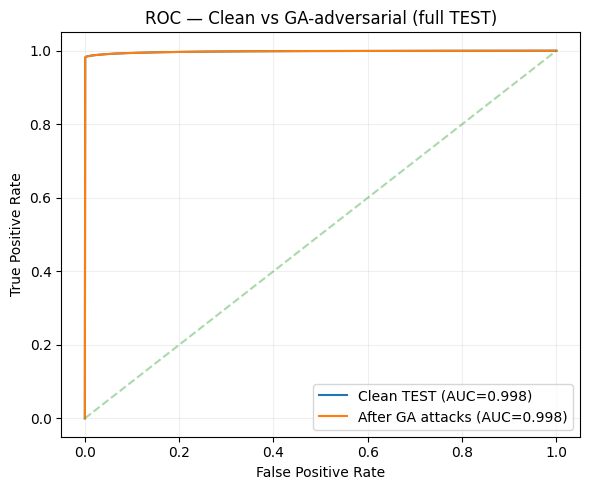

In [ ]:
# === GA — rebuild adversarial TEST and evaluate before vs after ===

# 1) Make a copy of clean TEST features
X_test_ga = X_test_sel.copy()

# 2) Load GA adversarial rows if not already in memory
if "adv_rows_ga" not in globals():
    adv_rows_ga = np.load(OUT_DIR / "adv_rows_ga_family.npy", allow_pickle=True)

print("GA: loaded adversarial rows:", len(adv_rows_ga))

# 3) Apply GA edits into the copy (row-by-row)
for row in adv_rows_ga:
    ti, x_before, x_after = row
    ti = int(ti)
    X_test_ga.iloc[ti, :] = x_after  # overwrite that row with adversarial version

# 4) Predictions & probabilities: clean TEST vs GA-attacked TEST
y_bin = (y_test == "Malicious").astype(int).to_numpy()

proba_clean = rf.predict_proba(X_test_sel)[:, 1]
pred_clean  = rf.predict(X_test_sel)

proba_ga = rf.predict_proba(X_test_ga)[:, 1]
pred_ga  = rf.predict(X_test_ga)

# 5) Metrics helper
def metrics_from_pred(name, y_true_labels, y_pred_labels, y_true_bin, y_proba):
    acc  = accuracy_score(y_true_labels, y_pred_labels)
    prec = precision_score(y_true_labels, y_pred_labels, pos_label="Malicious")
    rec  = recall_score(y_true_labels, y_pred_labels, pos_label="Malicious")
    f1   = f1_score(y_true_labels, y_pred_labels, pos_label="Malicious")
    auc  = roc_auc_score(y_true_bin, y_proba)
    print(f"{name}: ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return acc, prec, rec, f1, auc

print("\n=== GA: global performance (whole TEST set) ===")
m_clean_ga = metrics_from_pred("Clean TEST", y_test, pred_clean, y_bin, proba_clean)
m_ga       = metrics_from_pred("After GA attacks", y_test, pred_ga, y_bin, proba_ga)

# 6) Evasion rate: among Malicious that RF originally caught, how many are flipped to Benign?
mask_mal_detected = (y_test == "Malicious") & (pred_clean == "Malicious")
total_detected    = int(mask_mal_detected.sum())

mask_flipped_ga = mask_mal_detected & (pred_ga == "Benign")
flipped_ga      = int(mask_flipped_ga.sum())

print(f"\nGA evasion on TEST: {flipped_ga} / {total_detected} originally detected Malicious "
      f"({(flipped_ga / max(total_detected,1)) * 100:.2f}% flipped to Benign)")

# 7) Optional ROC curve overlay (clean vs GA) — can be used for your ROC overlay figure
fpr_clean, tpr_clean, _ = roc_curve(y_bin, proba_clean)
fpr_ga,    tpr_ga,    _ = roc_curve(y_bin, proba_ga)

plt.figure(figsize=(6,5))
plt.plot(fpr_clean, tpr_clean, label=f"Clean TEST (AUC={m_clean_ga[4]:.3f})")
plt.plot(fpr_ga,    tpr_ga,    label=f"After GA attacks (AUC={m_ga[4]:.3f})")
plt.plot([0,1],[0,1],'--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Clean vs GA-adversarial (full TEST)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_clean_vs_ga.png", dpi=160)
print("Saved ROC overlay:", OUT_DIR / "roc_clean_vs_ga.png")


**PSO-Rebuild attack test, evaluate before vs after**

PSO: loaded adversarial rows: 61

=== PSO: global performance (whole TEST set) ===
Clean TEST: ACC=0.9922  PREC=0.9961  REC=0.9959  F1=0.9960  AUC=0.9976
After PSO attacks: ACC=0.9922  PREC=0.9961  REC=0.9959  F1=0.9960  AUC=0.9976

PSO evasion on TEST: 61 / 7161326 originally detected Malicious (0.00% flipped to Benign)
Saved ROC overlay: /content/drive/MyDrive/merged_data_results/roc_clean_vs_pso.png


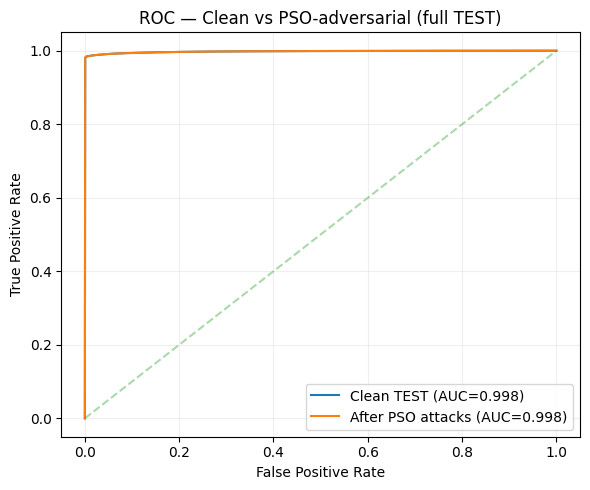

In [ ]:
# === 16B) PSO — rebuild adversarial TEST and evaluate before vs after ===
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 1) Make another copy of clean TEST features
X_test_pso = X_test_sel.copy()

# 2) Load PSO adversarial rows if not in memory
if "adv_rows_pso" not in globals():
    adv_rows_pso = np.load(OUT_DIR / "adv_rows_pso_family.npy", allow_pickle=True)

print("PSO: loaded adversarial rows:", len(adv_rows_pso))

# 3) Apply PSO edits into this copy
for row in adv_rows_pso:
    ti, x_before, x_after = row
    ti = int(ti)
    X_test_pso.iloc[ti, :] = x_after

# 4) Predictions & probabilities: clean TEST vs PSO-attacked TEST
y_bin = (y_test == "Malicious").astype(int).to_numpy()

proba_clean = rf.predict_proba(X_test_sel)[:, 1]
pred_clean  = rf.predict(X_test_sel)

proba_pso = rf.predict_proba(X_test_pso)[:, 1]
pred_pso  = rf.predict(X_test_pso)

def metrics_from_pred(name, y_true_labels, y_pred_labels, y_true_bin, y_proba):
    acc  = accuracy_score(y_true_labels, y_pred_labels)
    prec = precision_score(y_true_labels, y_pred_labels, pos_label="Malicious")
    rec  = recall_score(y_true_labels, y_pred_labels, pos_label="Malicious")
    f1   = f1_score(y_true_labels, y_pred_labels, pos_label="Malicious")
    auc  = roc_auc_score(y_true_bin, y_proba)
    print(f"{name}: ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return acc, prec, rec, f1, auc

print("\n=== PSO: global performance (whole TEST set) ===")
m_clean_pso = metrics_from_pred("Clean TEST", y_test, pred_clean, y_bin, proba_clean)
m_pso       = metrics_from_pred("After PSO attacks", y_test, pred_pso, y_bin, proba_pso)

# 5) Evasion rate for PSO
mask_mal_detected = (y_test == "Malicious") & (pred_clean == "Malicious")
total_detected    = int(mask_mal_detected.sum())

mask_flipped_pso = mask_mal_detected & (pred_pso == "Benign")
flipped_pso      = int(mask_flipped_pso.sum())

print(f"\nPSO evasion on TEST: {flipped_pso} / {total_detected} originally detected Malicious "
      f"({(flipped_pso / max(total_detected,1)) * 100:.2f}% flipped to Benign)")

# 6) Optional ROC overlay (clean vs PSO)
fpr_clean, tpr_clean, _ = roc_curve(y_bin, proba_clean)
fpr_pso,   tpr_pso,   _ = roc_curve(y_bin, proba_pso)

plt.figure(figsize=(6,5))
plt.plot(fpr_clean, tpr_clean, label=f"Clean TEST (AUC={m_clean_pso[4]:.3f})")
plt.plot(fpr_pso,   tpr_pso,   label=f"After PSO attacks (AUC={m_pso[4]:.3f})")
plt.plot([0,1],[0,1],'--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Clean vs PSO-adversarial (full TEST)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_clean_vs_pso.png", dpi=160)
print("Saved ROC overlay:", OUT_DIR / "roc_clean_vs_pso.png")


**GA vs PSO summary table (AUC drop + evasion rate)**

In [ ]:
# === GA vs PSO summary: AUC drop + evasion rate ===

# Clean AUC should be the same in both cells, but we’ll take from GA side
auc_clean = float(m_clean_ga[4])   # index 4 = AUC in (ACC, PREC, REC, F1, AUC)

auc_ga  = float(m_ga[4])
auc_pso = float(m_pso[4])

# Recompute total_detected in a consistent way
y_bin_labels   = (y_test == "Malicious")
pred_clean_all = rf.predict(X_test_sel)
mask_mal_detected = y_bin_labels & (pred_clean_all == "Malicious")
total_detected = int(mask_mal_detected.sum())

# Evasion rates that we already computed in the GA/PSO cells
ev_rate_ga  = (flipped_ga  / max(total_detected, 1)) * 100.0
ev_rate_pso = (flipped_pso / max(total_detected, 1)) * 100.0

summary_df = pd.DataFrame({
    "Method":        ["GA", "PSO"],
    "Clean AUC":     [auc_clean, auc_clean],
    "AUC after":     [auc_ga, auc_pso],
    "AUC drop":      [auc_clean - auc_ga, auc_clean - auc_pso],
    "Evasion rate %":[ev_rate_ga, ev_rate_pso],
    "Flips (M→B)":   [flipped_ga, flipped_pso],
    "Orig. detected Malicious": [total_detected, total_detected],
})

print("\n=== GA vs PSO summary (full TEST set) ===")
print(summary_df.to_string(index=False))

# Optional: save to CSV for report
summary_path = OUT_DIR / "ga_pso_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("\nSaved GA/PSO summary to:", summary_path)



=== GA vs PSO summary (full TEST set) ===
Method  Clean AUC  AUC after  AUC drop  Evasion rate %  Flips (M→B)  Orig. detected Malicious
    GA   0.997649   0.997647  0.000001        0.000768           55                   7161326
   PSO   0.997649   0.997647  0.000002        0.000852           61                   7161326

Saved GA/PSO summary to: /content/drive/MyDrive/merged_data_results/ga_pso_summary.csv


**Bar chart for acc/prec/rec/f1**

In [ ]:
def rebuild_adv_test(tag):
    """
    Build a full TEST set where the successfully attacked rows
    are replaced by their adversarial versions.

    tag: 'ga' or 'pso'
    """
    # Start from clean test set
    X_base = X_test_sel.copy()

    if tag == "ga":
        # these should be created in your GA cell
        # X_ga_adv:   adversarial samples
        # ga_succ_idx: indices in X_test_sel that were successfully attacked
        X_base[ga_succ_idx] = X_ga_adv
        return X_base, ga_succ_idx, None

    elif tag == "pso":
        # similarly for PSO
        X_base[pso_succ_idx] = X_pso_adv
        return X_base, pso_succ_idx, None

    else:
        print("Unknown tag:", tag)
        return None, None, None

In [ ]:
def eval_and_plot_metrics(tag: str):
    """
    Compute and plot metrics for CLEAN vs ADV (GA or PSO).
    tag: 'ga' or 'pso'
    """

    # ===== SELECT ATTACKED TEST SET =====
    if tag == "ga":
        X_adv = X_test_ga       # <<<<<< CHANGE THIS TO YOUR VARIABLE NAME
    elif tag == "pso":
        X_adv = X_test_pso      # if you have PSO later
    else:
        print("Unknown tag:", tag)
        return

    # ===== LABELS =====
    y_true = (y_test == "Malicious").astype(int).values

    # ===== PREDICTIONS =====
    y_pred_clean = (rf.predict(X_test_sel) == "Malicious").astype(int)
    y_pred_adv   = (rf.predict(X_adv)      == "Malicious").astype(int)

    # ===== METRICS =====
    def metric_dict(y_true, y_pred):
        return {
            "ACC": accuracy_score(y_true, y_pred),
            "PREC": precision_score(y_true, y_pred, zero_division=0),
            "REC": recall_score(y_true, y_pred, zero_division=0),
            "F1":  f1_score(y_true, y_pred, zero_division=0),
        }

    clean_res = metric_dict(y_true, y_pred_clean)
    adv_res   = metric_dict(y_true, y_pred_adv)

    print("Clean  :", clean_res)
    print(f"After {tag.upper()}:", adv_res)
    print("Drops  :", {k: clean_res[k] - adv_res[k] for k in clean_res.keys()})

    # ===== BAR CHART =====
    labels = ["ACC", "PREC", "REC", "F1"]
    clean_vals = [clean_res[k] for k in labels]
    adv_vals   = [adv_res[k]   for k in labels]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, clean_vals, width, label="Clean")
    plt.bar(x + width/2, adv_vals,   width, label=tag.upper())

    plt.xticks(x, ["Accuracy", "Precision", "Recall", "F1"])
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(f"Clean vs {tag.upper()} — Random Forest")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()

Clean  : {'ACC': 0.9922269845467346, 'PREC': 0.9961186385746457, 'REC': 0.9959216493858971, 'F1': 0.9960201342403227}
After GA: {'ACC': 0.9922195144113173, 'PREC': 0.996118608880713, 'REC': 0.9959140005662908, 'F1': 0.9960162942155006}
Drops  : {'ACC': 7.4701354173534185e-06, 'PREC': 2.9693932646068788e-08, 'REC': 7.648819606353996e-06, 'F1': 3.840024822010513e-06}


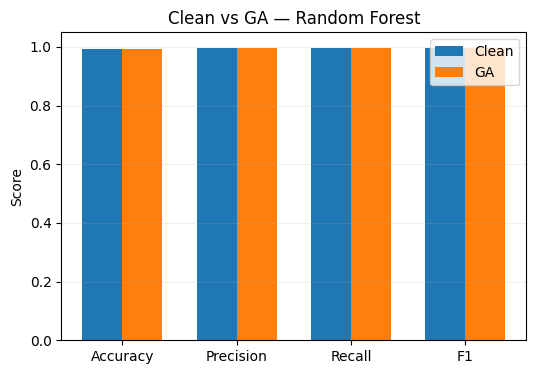

In [ ]:
eval_and_plot_metrics("ga")

Clean  : {'ACC': 0.9922269845467346, 'PREC': 0.9961186385746457, 'REC': 0.9959216493858971, 'F1': 0.9960201342403227}
After PSO: {'ACC': 0.9922186994874537, 'PREC': 0.9961186056413475, 'REC': 0.9959131661496065, 'F1': 0.9960158753019248}
Drops  : {'ACC': 8.28505928096579e-06, 'PREC': 3.293329819964441e-08, 'REC': 8.483236290657281e-06, 'F1': 4.258938397838641e-06}


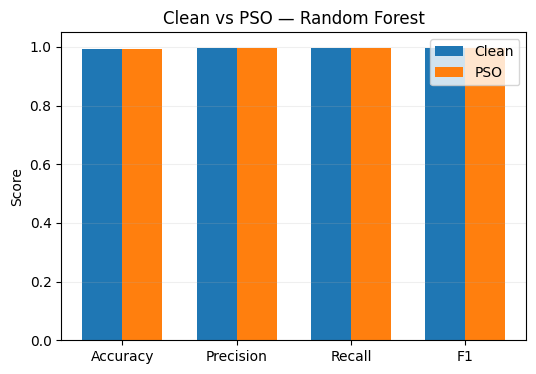

In [ ]:
eval_and_plot_metrics("pso")

**Most Frequently Modified Features (GA/PSO) bar chart**

In [ ]:
def plot_top_changed_features(tag: str, top_k: int = 10, eps: float = 1e-12):
    """
    Plot which features are modified most often by GA/PSO.
    tag: 'ga' or 'pso'
    """
    if tag == "ga":
        adv_deltas = adv_deltas_ga      # <-- your GA delta list
    elif tag == "pso":
        adv_deltas = adv_deltas_pso     # <-- CHANGE to your PSO delta list
    else:
        print("Unknown tag:", tag)
        return

    if adv_deltas is None or len(adv_deltas) == 0:
        print("No adversarial deltas found for", tag)
        return

    D = np.vstack(adv_deltas)
    changed = np.abs(D) > eps
    freq = changed.mean(axis=0)

    s = pd.Series(freq, index=X_test_sel.columns)
    s = s.sort_values(ascending=False).head(top_k)

    plt.figure(figsize=(7, 4))
    plt.barh(s.index, s.values)
    plt.gca().invert_yaxis()
    plt.xlabel("Fraction of attacked samples modified")
    plt.title(f"Most Frequently Modified Features ({tag.upper()})")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    csv_path = OUT_DIR / f"{tag}_top_changed_features.csv"
    s.to_csv(csv_path, header=["fraction_modified"])
    print("Saved:", csv_path)

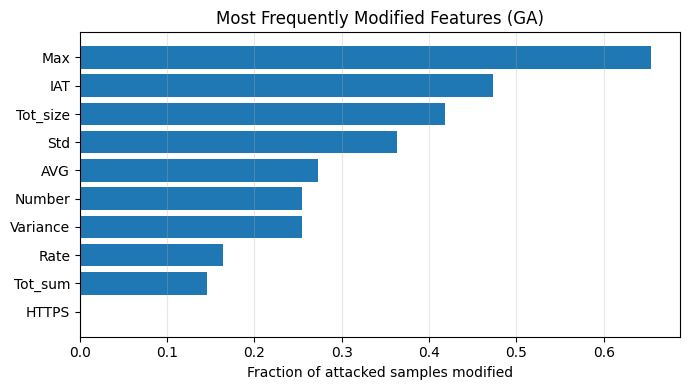

Saved: /content/drive/MyDrive/merged_data_results/ga_top_changed_features.csv


In [ ]:
plot_top_changed_features("ga")


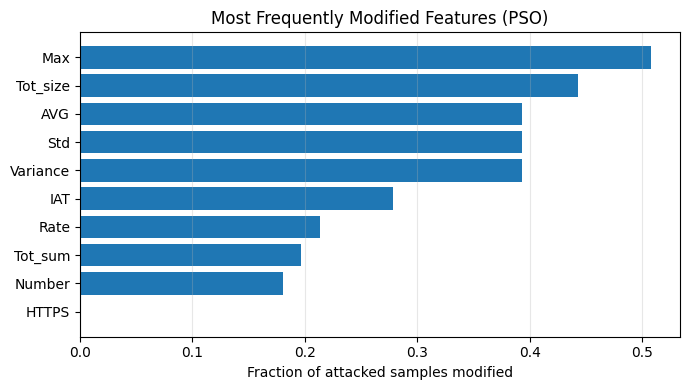

Saved: /content/drive/MyDrive/merged_data_results/pso_top_changed_features.csv


In [ ]:
plot_top_changed_features("pso")

**Confusion matrices (Clean vs GA / PSO)**

In [ ]:
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices(tag: str):
    """
    Plot confusion matrices for:
      - Clean TEST
      - GA- or PSO-attacked TEST

    tag: 'ga' or 'pso'
    """
    tag = tag.lower()

    # 1. Choose attacked test set
    if tag == "ga":
        X_adv = X_test_ga          # GA attacked TEST set
    elif tag == "pso":
        X_adv = X_test_pso         # <-- REPLACE with your PSO attacked TEST set
    else:
        print("Unknown tag:", tag)
        return

    # 2. True labels 0/1
    y_true = (y_test == "Malicious").astype(int).values

    # 3. Predictions
    y_pred_clean = (rf.predict(X_test_sel) == "Malicious").astype(int)
    y_pred_adv   = (rf.predict(X_adv)      == "Malicious").astype(int)

    # 4. Confusion matrices
    cm_clean = confusion_matrix(y_true, y_pred_clean, labels=[0, 1])
    cm_adv   = confusion_matrix(y_true, y_pred_adv,   labels=[0, 1])

    # 5. Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    disp_clean = ConfusionMatrixDisplay(
        confusion_matrix=cm_clean,
        display_labels=["Benign", "Malicious"]
    )
    disp_clean.plot(ax=axes[0], colorbar=False)
    axes[0].set_title("Clean TEST")

    disp_adv = ConfusionMatrixDisplay(
        confusion_matrix=cm_adv,
        display_labels=["Benign", "Malicious"]
    )
    disp_adv.plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f"{tag.upper()}-attacked TEST")

    plt.tight_layout()
    plt.show()

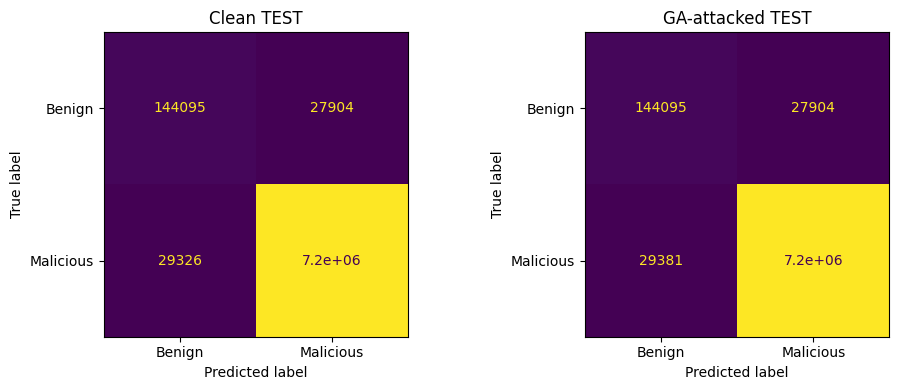

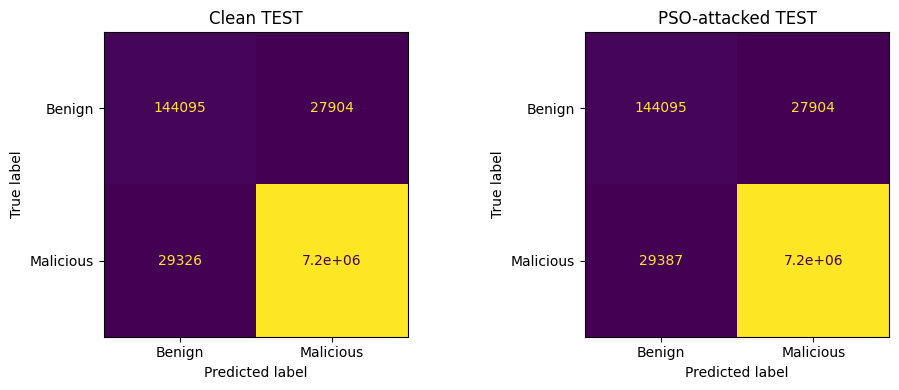

In [ ]:
plot_confusion_matrices("ga")   # Clean vs GA
plot_confusion_matrices("pso")  # Clean vs PSO (after you set X_test_pso)